Before you turn this problem in, make sure everything runs as expected. First, **restart the kernel** (in the menubar, select Kernel$\rightarrow$Restart) and then **run all cells** (in the menubar, select Cell$\rightarrow$Run All).

Make sure you fill in any place that says `YOUR CODE HERE` or "YOUR ANSWER HERE", as well as any collaborators you worked with:

In [1]:
COLLABORATORS = ""

## To receive credit for this assignment, you must also fill out the [AI Use survey](https://forms.gle/ZhR5k8TdAeN8rj4CA)


---

In [11]:
from __future__ import print_function
%matplotlib inline
import numpy
import matplotlib.pyplot as plt

# import the factorial function from scipy
from scipy.special import factorial
import scipy

# HW 1:  Forms of Error



## Question 1:  definition of errors

**(a)**  [4 pts] Write a short python program to calculate and return, the absolute error, relative error and degree of decimal precision (as defined in class) given an object `f` and its approximation `F`.  Note, both `f` and `F` can be numpy arrays.

In [14]:
def errors(f,F):
    """ calculate various measures of error of an object f and its approximation F
    
    Parameters
    ----------
    f:  numpy.array (or float)
        array of true values
        
    F: numpy.array
        array of approximate values
        
    Returns
    -------
    
    e: array of absolute errors
    r: array of relative errors
    p: integer array of precisions
    """
    
    # YOUR CODE HERE
    e = abs(f-F)
    # r = numpy.where(numpy.abs(f)!=0,e / numpy.abs(f),0)
    r = e / numpy.abs(f)
    p = numpy.floor(-numpy.log10(r/5.))


    # raise NotImplementedError()
    return e, r, p


In [4]:
# you can test your code here
x = [1., 2., 3.]
f = numpy.exp(x)
F = [ 2.718,  7.389,  20.085]
e,r,p = errors(f,F)
print(r)

print(numpy.abs([-1,3,4]))

[1.03678896e-04 7.59216467e-06 2.67318315e-05]
[1 3 4]


In [19]:
# Testing Cell (do not copy)

# Test Simple Scalars
e,r,p = errors(numpy.exp(1),2.72)
answer = [0.0017181715409551046, 0.0006320799863232398, 3]
numpy.testing.assert_allclose([e,r,p], answer)
print('passed scalar test')

# Test with array input
x = [1., 2., 3.]
f = numpy.exp(x)
F = [ 2.718,  7.389,  20.085]
e,r,p = errors(f,F)
numpy.testing.assert_allclose(e,[2.81828459e-04, 5.60989307e-05, 5.36923188e-04])
numpy.testing.assert_allclose(r,[1.03678896e-04, 7.59216467e-06, 2.67318315e-05])
numpy.testing.assert_allclose(p,[4, 5, 5])
print('passed array test')

passed scalar test
passed array test


**(b)** [2 pts]  Use your routine to compare the absolute error, relative error and degree of precision for these two rational approximations of $\pi$

* $f = \pi$ and $F = 22 / 7$
* $f = \pi$ and $F = 355 / 113$

Which is more accurate?

In [6]:
# you can put some working code here to generate your answers, but put your answers in the cell below
e1,r1,p1 = errors(f=numpy.pi,F=22/7)
e2,r2,p2 = errors(f=numpy.pi,F=355/113)

print(e1,r1,p1)
print(e2,r2,p2)

0.0012644892673496777 0.0004024994347707008 4.0
2.667641894049666e-07 8.49136787674061e-08 7.0


The second option, F2=355/113, is more accurate than F1=22/7. The number of digits of decimal precision is 7 for F2=355/113 and 4 for F1=22/7. The absolute and relative error of F2 is also much less than that of F1. Thus, F2 is more precise

**(c)** [6 pts] Write a python routine to find the most accurate $d$ digit rational approximation to $\pi$. i.e. find
two $d$ digit positive integers $m,n$ such that 

$$ F = \frac{m}{n} \sim \pi$$

(hint:  $355/113$ is the best 3-digit rational approximation)

In [7]:
def rational_pi(d):
    ''' Find the best rational approximation to pi ~ m/n where m and n are both d-digit positive integers
    
    Parameters
    ----------
    
    d: int
        number of digits in both m and n
    
    Returns
    -------
    m,n: int
        numerator and denominator of best d digit rational approximation to pi ~ m/n
        
    '''
    
    best_e = float('inf')
    m_best=0
    n_best=0
    for m in range(10**(d-1),10**d):
        for n in range(10**(d-1),10**d):
            # if m/n not in arr_tested: # this makes it slower it seems
                # arr_tested = numpy.append(arr_tested,m/n)
            # e,r,p = errors(f=numpy.pi,F=m/n)
            e = abs(numpy.pi-m/n)
            if e < best_e:
                best_e = e
                m_best = m
                n_best = n

    return m_best,n_best

In [8]:
# Use this cell to mess with your code

# def rational_pi_fast(d):
#     # Create grid of all m/n combinations
#     print('here2')
#     m_vals = numpy.arange(10**(d - 1), 10**d)
#     n_vals = numpy.arange(10**(d - 1), 10**d)
#     print('here1')
#     M, N = numpy.meshgrid(m_vals, n_vals, indexing='ij')  # M.shape = (n_m, n_n)
#     print('here')

#     e, r, p = errors(f=numpy.pi, F=M/N)
#     min_idx = numpy.unravel_index(numpy.argmin(r), r.shape)

#     return M[min_idx], N[min_idx]

In [8]:
# Testing Cell (do not copy)

# print out best rational approximations and their errors  for d =1-5
for d in range(1,6):
    m,n = rational_pi(d)
    e,r,p = errors(numpy.pi,m/n)
    print('d={}: {}/{} = {}:\t e = {},\t, r = {},\t p= {}'.format(d,m,n,m/n,e,r,p))
    
# Run assertion Tests
numpy.testing.assert_allclose(rational_pi(2),(44, 14))
numpy.testing.assert_allclose(rational_pi(3),(355, 113))
print('\nsuccess!')


d=1: 3/1 = 3.0:	 e = 0.14159265358979312,	, r = 0.04507034144862795,	 p= 2.0
d=2: 44/14 = 3.142857142857143:	 e = 0.0012644892673496777,	, r = 0.0004024994347707008,	 p= 4.0
d=3: 355/113 = 3.1415929203539825:	 e = 2.667641894049666e-07,	, r = 8.49136787674061e-08,	 p= 7.0
d=4: 3195/1017 = 3.1415929203539825:	 e = 2.667641894049666e-07,	, r = 8.49136787674061e-08,	 p= 7.0
d=5: 99733/31746 = 3.1415926415926414:	 e = 1.1997151716514054e-08,	, r = 3.818811997413258e-09,	 p= 9.0

success!


**(d)** [6 pts] $F = n \log(n) - n$ is Stirling's approximation to  $f = \log(n!)$ for large values of $n$. 
Do the following

* Make a plot showing the relative error and degree of decimal precision for $f$ and $F$ as a function of integer $n$

* Estimate the smallest value of $n$ where Stirling's approximation is good to 4 decimal places of precision.  

**Note**: If you use the `factorial` function imported from `scipy.special`, you will not be able to answer this question.  **Why?**  

**Hint**: However there is another way to evaluate $\log(n!)$ for integer $n$ that will work.

1452


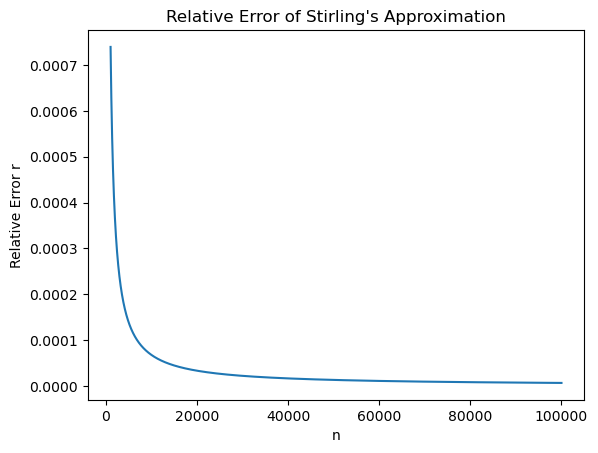

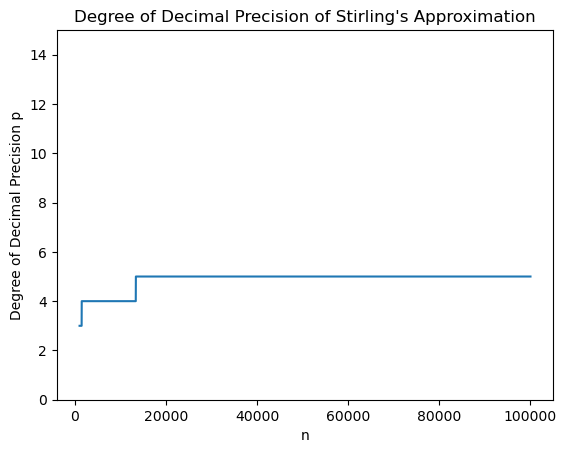

In [36]:
# YOUR CODE HERE
import scipy
import matplotlib.pyplot as plt
import math

n = numpy.arange(1000,100000)
F = n*numpy.log(n) - n
f = scipy.special.gammaln(n + 1)
e,r,p = errors(f,F)

plt.figure(1)
plt.plot(n,r)
plt.title("Relative Error of Stirling's Approximation")
plt.xlabel("n")
plt.ylabel("Relative Error r")

plt.figure(2)
plt.plot(n,p)
plt.title("Degree of Decimal Precision of Stirling's Approximation")
plt.xlabel("n")
plt.ylabel("Degree of Decimal Precision p")
plt.ylim([0,15])


# Estimate the smallest value of n where Stirling's approximation is good to 4 decimal places of precision
i=0
for po in p:
    if po==4:
        break
    i+=1

print(n[i])

You can't use scipy.special.factorial() because if you do n! first, since the factorial value of n grows super fast, with relatively small values of n you will get memory issues. We are looking at large values of n in this question so this could be problematic.

The smallest value of n where Stirling's approximation reaches 4 decimals of precision is at n=1452.

## Question 2:  The great Exp challenge...

Here you will attempt to write a function to calculate $e^x$ using its Taylor polynomial approximation expanded around $x_0=0$

$$e^x \approx T_n(x) = 1 + x + \frac{x^2}{2!} + \frac{x^3}{3!} + \cdots + \frac{x^n}{n!}$$

such that the relative error of $f=e^x$ and $F=T_n(x)$ is of order Machine epsilon ($\epsilon_{machine}$) for  $x\in[-50,50]$.  This problem is actually a bit of a stinker and takes a bit of thought (particularly for $x<0$).  But I'll work you through it.

**(a)** [4 pts] Assume $x> 0$ and show that the upper bound on the *relative error*  at term $n$ 

$$r_n = \frac{|e^x - T_n(x)|}{|e^x|}$$

is given by

$$r_n \leq \left | \frac{x^{n+1}}{(n + 1)!} \right |$$


For any continuous and differentiable function $f(x)$, $f(x)=T_n(x) + R_n(x)$, where $T_n(x)$ is the Taylor series of $f(x)$ with terms up to $n$, and $R_n(x)$ is the remainder of $f(x)$ missing from $T_n(x)$ (the remaining terms in this Taylor series to an infinite number of terms).

If we consider $R_n(x)$ with only the $n+1$ term, where $n$ is the number of terms included in $T_n(x)$, this is now an approximation for the remainder, and this approximation will be an upper bound on $r_n$ since any term after the $n+1$ term added to $R_n(x)$ will be making $R_n \simeq f(x)$, which would decrease $r_n$.

Now consider $f(x)=e^x$

$r_n \leq \frac{|R_n|}{|e^x|}$

$\frac{|R_n|}{|e^x|} = |\frac{ \frac{x^{n+1}}{(n+1)!} }{e^x}|$

For any $x>0$, the fraction in the equation immediately above this line always gets smaller if $x$ increases. So we will just exclude the denominator since the $x=0$ option is an upper bound on $r_n$. Thus, the upper bound on $r_n$ can be written as: 

$r_n \leq | \frac{x^{n+1}}{(n+1)!} |$

**(b)** [4 pts] Analytically show that for **large** $x\gg1$ and $n$, $r_n \leq \epsilon_{\text{machine}}$ implies that we need *approximately* $n > e \cdot x$ terms in the series (where $e = \text{exp}(1)$).

*Hint* Use Stirling's approximation $log (n!) \approx n~log~n - n$ (and then this problem is still a bit tricky)

$$
r_n \leq \epsilon_m \\
\log{r_n} \leq \log{\epsilon_m} \\
\log{x^{n+1}} - log{(n+1)!} \leq \log{\epsilon_m} \\
$$

Now use Stirling's approximation.

$$
(n+1) \log{x} - (n+1) \log{n+1} + (n+1) \leq \log{\epsilon_m} \\
(n+1) (\log{x} - \log{n+1} + 1) \leq \log{\epsilon_m} \\
(n+1) (\log{\frac{x}{n+1}} + 1) \leq \log{\epsilon_m} \\
$$

We will guess $n>ex$, and plug in $n=ex$.
We are told to assume $x>>1$, thus, $ex+1 \approx ex$.

$$
ex(\log{e^-1}+1) = ex(-1+1) = 0 \leq \log(\epsilon_m)
$$

We know that $\leq \log(\epsilon_m)$ is very negative since $\epsilon_m$ is very small, so we need more terms than $ex$ to satisfy this inequality, hence $n>ex$.

**(c)** [6 pts] Use this result to write a Python function that accurately approximates $e^x$ using $T_n(x)$ for scalar $x$ and returns both the estimate and the number of terms in the series.  Note that the testing tolerance will be $8 \cdot \epsilon_{\text{machine}}$ over the range $x\in[-50,50]$

Make sure to document your code including expected inputs, outputs, and assumptions being made.

Some Hints:
* To make your life easier,  we will assume $x$ and $T_n(x)$ are just of type float (not arrays)
* Think about how we evaluated polynomials efficiently in class
* $T_n(x)$ for $x<0$ is a highly unstable alternating series with severe cancellation issues. However, there is a simple fix that will return accurate solutions independent of the sign of $x$

In [124]:
import scipy.sparse
import scipy.special


def Tn_exp(x,MAX_N=175):
    """ Approximate e^x using a Taylor series about zero up to n terms in this Taylor series
    
    Parameters:
    -----------
        x: float
            scalar value to approximate exp(x)
    """

    def eval_poly(p, x):
        '''Evaluates a polynomial using Horner's method given coefficients p at x
        
        The polynomial is defined as
        
            P(x) = p[0] x**n + p[1] x**(n-1) + ... + p[n-1] x + p[n]
            
        Parameters:
            p: list or numpy array of coefficients 
            x:  scalar float
            
        returns:
            P(x):  value of the polynomial at point x (float)
        
        '''
        
        y = p[0]
        for element in p[1:]:
            y = y*x + element
            
        return y

    assert(isinstance(x,float))
    # rough estimate of maximum number of steps for large x
    MAX_N = int(8*numpy.exp(1)*abs(x)) + 100 # use n>e*x but add 100 to 8*e*x because we found in part b we need to be well above 8*e*x
    # MAX_N = 175
    # T_n=1
    p = numpy.zeros((MAX_N))
    if x>0:
        i=0
        for n in range(0,MAX_N):
            # T_n += (x**n) / scipy.special.factorial(n)
            # T_n += (x/(scipy.special.factorial(n)**(1/n)))**n
            # T_n += numpy.exp(n * numpy.log(x)) - scipy.special.factorial(n)
            p[i] = 1/scipy.special.factorial(n)
            i+=1
        T_n = eval_poly(numpy.flip(p),x) # flip to align with how eval_poly is written
            
    else: 
        x=abs(x)
        # for n in range(1,MAX_N):
        #     T_n += (x**n) / scipy.special.factorial(n)
        #     # T_n += numpy.exp(n * numpy.log(x)) - scipy.special.factorial(n)
        # T_n = T_n ** (-1)
        i=0
        for n in range(0,MAX_N):
            p[i] = 1/scipy.special.factorial(n)
            i+=1
        T_n = eval_poly(numpy.flip(p),x) # flip to align with how eval_poly is written
        T_n = T_n ** (-1) # e^x = 1/e^-x trick
        
    return T_n, MAX_N

In [86]:
# Feel free to test your code here and/or make a plot of errors
print(Tn_exp(50.))

(np.float64(5.184705528587032e+21), 1087)


In [134]:
# Testing Cell (do not copy)

x = numpy.linspace(-50, 50, 101)
eps = numpy.finfo(float).eps
tolerance = 8 * eps

answer = numpy.zeros(x.shape)
N = numpy.zeros(x.shape)
for i,xi in enumerate(x):
    answer[i], N[i] = Tn_exp(xi)
r = numpy.abs(answer - numpy.exp(x)) / numpy.abs(numpy.exp(x))
print('maxmimum relative error = {} eps_machine'.format(r.max()/eps))
assert(numpy.all(r  < tolerance))
print("Success!")

maxmimum relative error = 4.252190255480811 eps_machine
Success!


**(d)** [4 pts] In ieee double precision,  the largest value of $x$ that has $e^x<$ `numpy.finfo(float).max` is about 709 (i.e. `numpy.log(numpy.finfo(float).max))`. 

* What is the relative error in units of machine epsilon for your routine and `f=numpy.exp(709)`
* What is the relative error in units of machine epsilon for `F=numpy.exp(1)**709` and `f=numpy.exp(709)`

Explain your results

In [126]:
Tn_out = Tn_exp(709.,MAX_N=100)
print(Tn_out,numpy.exp(709))
r_me = abs(Tn_out[0] - numpy.exp(709)) / numpy.exp(709)
r_other = abs(numpy.exp(1)**709 - numpy.exp(709)) / numpy.exp(709)
eps_m = numpy.finfo(float).eps
print(r_me/eps_m) # units of machine error
print(r_other/eps_m) # units of machine error

(np.float64(7.37704835207159e+177), 15518) 8.218407461554972e+307
4503599627370496.0
170.0702257577037


The relative error is extremely high for my routine. This is probably because I need to modify it to be able to take in higher values of n without overflowing. I tried some things but I couldn't get them to work. The relative error for the second part of this problem is surprisingly high even though F and f are separated by one operation. However, doing another operation introduces more floating point errors, and so this manifests here.

**(e)** **Extra Credit**

[4 pts] Can you modify your routine for `Tn_exp(x)`) to approximate $e^x$ on the range $x\in[-709, 709]$ to within 16 $\epsilon_{machine}$?


In [ ]:
# YOUR CODE HERE
raise NotImplementedError()

In [ ]:
x = numpy.linspace(-709, 709, 101)
tolerance = 16 * eps

answer = numpy.zeros(x.shape)
N = numpy.zeros(x.shape)
for i,xi in enumerate(x):
    answer[i], N[i] = Tn_exp(xi, tolerance=tolerance)
r = numpy.abs(answer - numpy.exp(x)) / numpy.abs(numpy.exp(x))
print('maxmimum relative error = {} eps_machine'.format(r.max()/eps))
assert(numpy.all(r  < tolerance))
print("Success!")

## Question 3

Consider a computing system that uses deoxyribonucleic acid (DNA) to store information.  Given that DNA is formed from the 4 nucleobases adenine, cytosine, guanine, and thymine,  let us assume that our storage of numbers will be base 4.  Answer the following questions based on this assuming that we have $p=3$ for the mantissa and the exponent $E \in [-3, 3]$ (and we'll pretend DNA has a sign bit...chirality?).

**(a)** [4 pts] How many numbers can we represent with this floating point system (assume it's normalized)?  What are the underflow and overflow limits? What is machine Epsilon?

In [131]:
# representable numbers:  sign bit (2), d1 normalized (3), d2 (4), d3 (4), E (7), zero (+1)
num_total = 2*3*4*4*7+1

# Overflow limit
F_max = 9.99*(4**3)

# Underflow limit
F_min = 1.00*(4**-3)

# Machine epsilon, smallest esp_m that makes 1+esp_m > 1
one = 1.00 * (4**0)
one_next = 1.01 * (4**0)
eps_m = one_next - one

print(num_total)
print(F_max,F_min)
print(eps_m)


673
639.36 0.015625
0.010000000000000009


We can represent 673 numbers. Overflow limit is 639.36. Underflow limit is 0.015625. Machine epsilon is 0.01.

**(b)** [4pts] Graphically show how the numbers on the decimal real line are distributed.

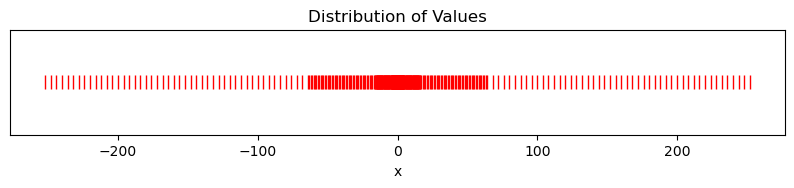

In [132]:
d_1_values = [1, 2, 3]
d_2_values = [0, 1, 2, 3]
d_3_values = [0, 1, 2, 3]
E_values = [0, -1, -2, -3, 1, 2, 3]

fig = plt.figure(figsize=(10.0,3.0))
axes = fig.add_subplot(2, 1, 1)

for E in E_values:
    for d1 in d_1_values:
        for d2 in d_2_values:
            for d3 in d_3_values:
                axes.plot( (d1 + d2 * (1/4) + d3 * (1/16)) * 4**E, 0.0, 'r|', markersize=10)
                axes.plot(-(d1 + d2 * (1/4) + d3 * (1/16)) * 4**E, 0.0, 'r|', markersize=10)
            
# axes.plot(0.0, 0.0, '|', markersize=20)
# axes.plot([-1., 1.], [0.0, 0.0], 'k|', markersize=30)

# axes.plot([-100.0, 100.0], [0.0, 0.0], 'k')

axes.set_title("Distribution of Values")
axes.set_yticks([])
axes.set_xlabel("x")
axes.set_ylabel("")

plt.show()


**(c)** [4 pts] For the same  range of $E$, estimate the ratio of numbers that can be stored in  $p$ base-pairs (base 4) versus $p$ bits (base 2).  Check your answer against the given problem with $p=3$ and $E\in[-3,3]$

In [133]:
# some noodle space for calculations if you want

'''
num_p4 / num_p2
representable numbers:  sign bit (2), d1 normalized (base-1), d2 (base), d3 (base), d... (base), E, zero (+1)

(2 * (4-1) * 4**(p-1) * E + 1) / (2 * (2-1) * 2**(p-1) * E + 1) ~ 3*(4**(p-1)) / 1*(2**(p-1)) ~ 3 * (2**(p-1))
'''

# Check: 
p=3
E=7
base2 = 2 * (2-1) * 2**(p-1) * E + 1
base4 = 2 * (4-1) * 4**(p-1) * E + 1
ratio_analytic = base4/base2
ratio_estimate = 3*(2**(p-1))

print(ratio_analytic,ratio_estimate)

11.807017543859649 12


$$
ratio \approx 3 * 2^{p-1}
$$

See code above for check, this estimate is pretty close and is derivated in the comments of the code in the block above this one.

$$

$$